In [593]:
# importing libraries
import math
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline


train=pd.read_csv("EvoChargeNaive.csv")
xls =pd.read_excel("BTS Data.xlsx")

In [594]:
xls_elec =pd.read_excel("fotw1275webxlsx.xlsx")
xls_elec.rename(
    columns={
        "Month-Year": "Date",
        "Electric Vehicles": "Monthly_EV_market_share%",
        "Plug-In Hybrid Electric Vehicles": "Monthly_PHEV_market_share%"
    },
    inplace=True
)

xls_elec=xls_elec.iloc[:, :-1]

    The instruction (in Spanish) means you must reconstruct monthly sales of PHEVs and EVs from Jan-2010 to Dec-2022 using two pieces of information in BTS Data.xlsx:
    
    Total vehicle sales per year (in millions of units) in the United States from 2010–2022.
    
    Average proportion of annual sales that occur in each month (Jan–Dec).
    
    Core Idea
    
    You distribute each year's total sales across the 12 months using the monthly proportions.
    
    So for each year:
    
    Monthly Salesy,m=Annual Salesy×Monthly Proportionm
    Monthly Sales
    y,m
    	​
    
    =Annual Sales
    y
    	​
    
    ×Monthly Proportion
    m
    	​
    
    
    Where:
    
    y
    y = year (2010–2022)
    
    m
    m = month (Jan–Dec)
    
    If proportions are percentages, convert them to decimals first.

In [595]:
# Remove the last row
xls = xls.iloc[:-1, :]

# Set "Year" as the index and drop the column
xls = xls.set_index("Year", drop=True)

# Display the dataframe
xls_1= xls.loc[:, ["Vehicles Sold (millions)"]]

xls_2= xls.loc[:, ["Month","\nAverage proportion of sales made each month"]].head(12)

In [596]:
df_sales= xls_1.reset_index()
df_sales["Vehicles Sold"]=df_sales["Vehicles Sold (millions)"]*1000000
df_sales.drop(columns=["Vehicles Sold (millions)"],inplace=True)

In [597]:
# Monthly proportion of sales (sum = 1)
monthly_proportion = xls_2["\nAverage proportion of sales made each month"].astype(float).to_list()

monthly_data = []

for _, row in df_sales.iterrows():
    year = int(row["Year"])
    annual_sales = float(row["Vehicles Sold"])
    
    cumulative = 0  # start at 0 for each year
    for month_index, month_prop in enumerate(monthly_proportion, start=1):
        monthly_sales = annual_sales * month_prop
        cumulative += monthly_sales
        
        monthly_data.append({
            "Date": pd.Timestamp(year=year, month=month_index, day=1),
            "Monthly_Sales": monthly_sales,
            "Cumulative_Sales": cumulative  # cumulative starting from 0 each year
        })

df_monthly = pd.DataFrame(monthly_data)
df_monthly

,Date,Monthly_Sales,Cumulative_Sales
0,2010-01-01,725650.0,725650.0
1,2010-02-01,762450.0,1488100.0
2,2010-03-01,964850.0,2452950.0
3,2010-04-01,885500.0,3338450.0
4,2010-05-01,868250.0,4206700.0
...,...,...,...
151,2022-08-01,1205410.0,9394450.0
152,2022-09-01,1370800.0,10765250.0
153,2022-10-01,1338020.0,12103270.0
154,2022-11-01,1321630.0,13424900.0


In [598]:
# months_df = xls_2[["Month", "\nAverage proportion of sales made each month"]]
# months_df.columns = ["Month","Prop"]

# df_monthly = (
#     df_sales.assign(key=1)
#     .merge(months_df.assign(key=1), on="key")
#     .drop("key", axis=1)
# )

# df_monthly["Monthly_Sales"] = (
#     df_monthly["Vehicles Sold (millions)"] * 1_000_000 * df_monthly["Prop"]
# )

# df_monthly["Date"] = pd.to_datetime(
#     df_monthly["Year"].astype(str) + "-" + df_monthly["Month"] + "-01"
# )

# df_monthly = df_monthly.sort_values("Date")

# df_monthly

In [599]:
import pandas as pd

# Market share for EVs and PHEVs per year
market_share = pd.DataFrame({
    "Year": list(range(2010, 2023)),
    "EV_Share": [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.12, 0.13, 0.14, 0.15],
    "PHEV_Share": [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07]
})

monthly_data_2 = []

# Initialize once (not inside loop)
monthly_total_cumsum = 0

for _, row in df_sales.iterrows():
    
    year = int(row["Year"])
    annual_sales = float(row["Vehicles Sold"])
    
    ev_share = market_share.loc[market_share["Year"] == year, "EV_Share"].iloc[0]
    phev_share = market_share.loc[market_share["Year"] == year, "PHEV_Share"].iloc[0]

    cumulative_ev = 0
    cumulative_phev = 0

    for month_index, month_prop in enumerate(monthly_proportion, start=1):

        monthly_total = annual_sales * month_prop

        # Global cumulative sum
        monthly_total_cumsum += monthly_total

        monthly_ev = monthly_total * ev_share
        monthly_phev = monthly_total * phev_share

        cumulative_ev += monthly_ev
        cumulative_phev += monthly_phev

        monthly_data_2.append({
            "Date": pd.Timestamp(year=year, month=month_index, day=1),
            "Monthly_Total": monthly_total,
            "Monthly_Total_cumsum": monthly_total_cumsum,
            "Monthly_EV": monthly_ev,
            "Monthly_PHEV": monthly_phev,
            "Cumulative_EV": cumulative_ev,
            "Cumulative_PHEV": cumulative_phev
        })

df_monthly_2 = pd.DataFrame(monthly_data_2)

print(df_monthly_2.head())

        Date  Monthly_Total  Monthly_Total_cumsum  Monthly_EV  Monthly_PHEV  \
0 2010-01-01       725650.0              725650.0     14513.0        7256.5   
1 2010-02-01       762450.0             1488100.0     15249.0        7624.5   
2 2010-03-01       964850.0             2452950.0     19297.0        9648.5   
3 2010-04-01       885500.0             3338450.0     17710.0        8855.0   
4 2010-05-01       868250.0             4206700.0     17365.0        8682.5   

   Cumulative_EV  Cumulative_PHEV  
0        14513.0           7256.5  
1        29762.0          14881.0  
2        49059.0          24529.5  
3        66769.0          33384.5  
4        84134.0          42067.0  


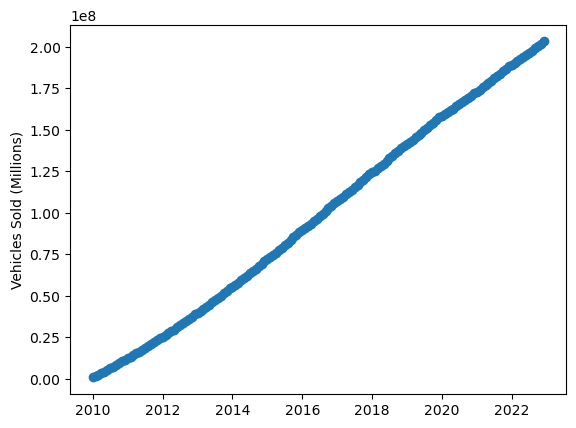

In [600]:
plt.plot(
    df_monthly_2["Date"],
    df_monthly_2["Monthly_Total_cumsum"],
    marker="o",
    linewidth=2,
    label="Total Vehicles"
)

plt.ylabel("Vehicles Sold (Millions)")
plt.show()

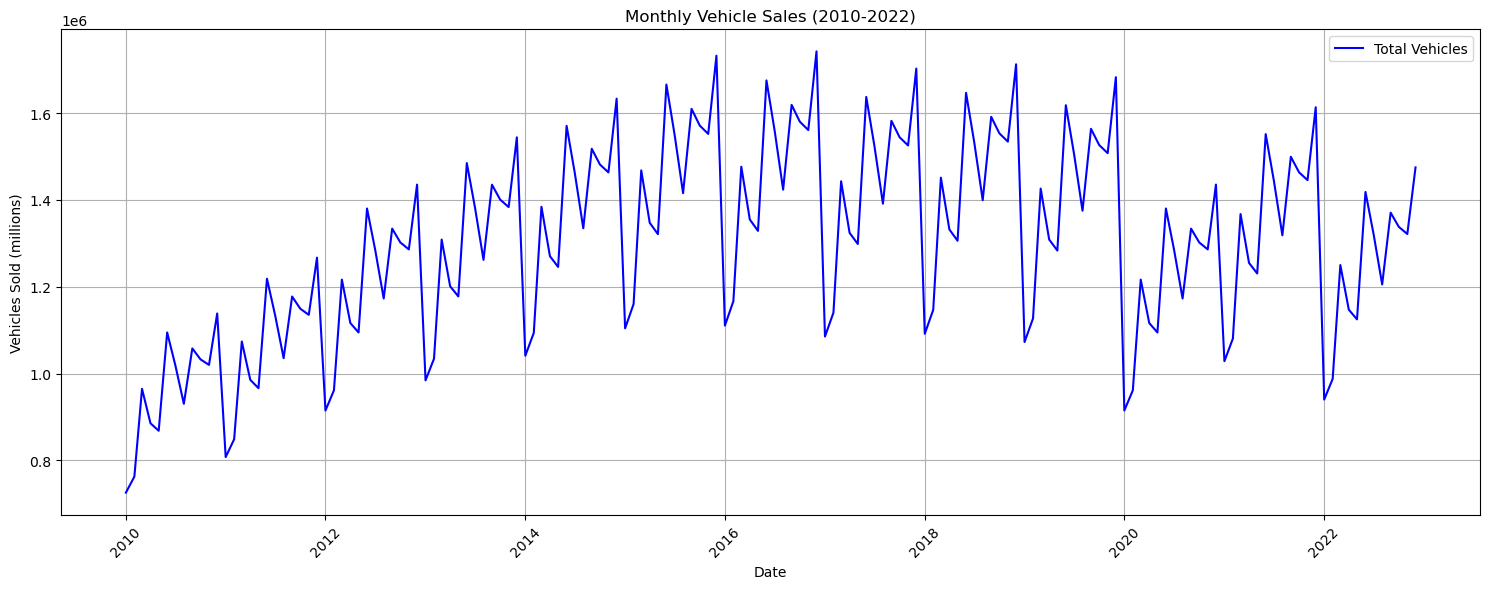

In [601]:
# Set figure size
plt.figure(figsize=(15,6))

# Plot each line
plt.plot(df_monthly_2["Date"], df_monthly_2["Monthly_Total"], label="Total Vehicles", color="blue")
# plt.plot(df_monthly_2["Date"], df_monthly_2["Monthly_EV"], label="EV Sales", color="green")
# plt.plot(df_monthly_2["Date"], df_monthly_2["Monthly_PHEV"], label="PHEV Sales", color="orange")

# Chart styling
plt.title("Monthly Vehicle Sales (2010-2022)")
plt.xlabel("Date")
plt.ylabel("Vehicles Sold (millions)")
plt.legend()
plt.grid(True)

# Rotate x-axis for readability (optional)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

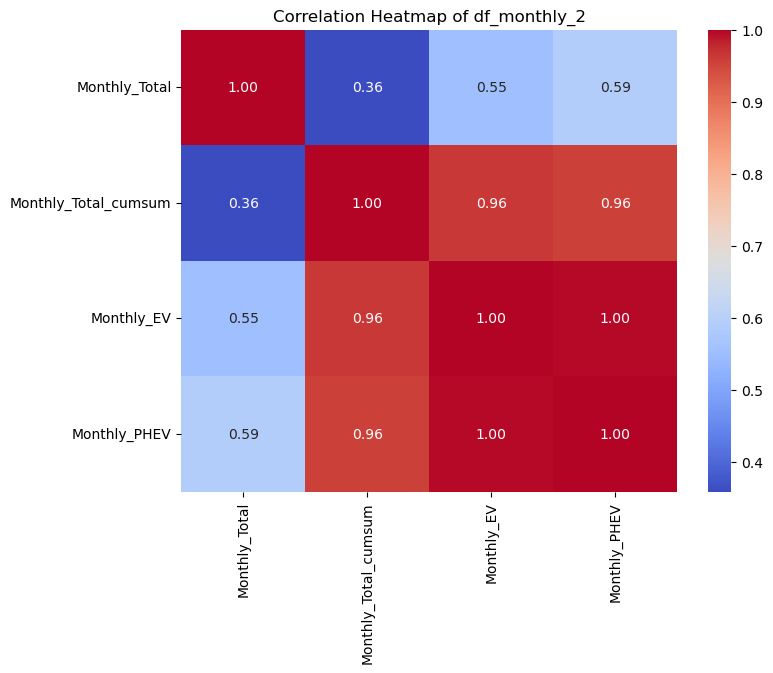

In [602]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix (excluding last two columns)
corr_matrix = df_monthly_2.set_index("Date").iloc[:, :-2].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap of df_monthly_2")
plt.show()

In [603]:
df_monthly= df_monthly_2.iloc[:, :-2]

# Define crises with start and end dates
crises_periods = {
    "Global_Financial_Crisis_Recovery": ("2010-01-01", "2011-12-31"),  # recovery period after 2008 crisis
    "Oil_Price_Crash": ("2014-06-01", "2016-01-31"),                    # oil price dropped
    "COVID19_Pandemic": ("2020-03-01", "2021-12-31"),                   # pandemic effect
    "Semiconductor_Shortage": ("2021-01-01", "2022-12-31"),             # global chip shortage
    "Energy_Crisis": ("2022-02-01", "2022-12-31"),                       # energy/gas price spike
}

# Initialize crisis columns with 0
for crisis in crises_periods.keys():
    df_monthly[crisis] = 0

# Fill 1 if the crisis was active
for crisis, (start, end) in crises_periods.items():
    start_date = pd.Timestamp(start)
    end_date = pd.Timestamp(end)
    df_monthly.loc[(df_monthly["Date"] >= start_date) & (df_monthly["Date"] <= end_date), crisis] = 1

In [604]:
df_monthly=df_monthly.merge(xls_elec,on=["Date"],how="inner")
df_monthly

,Date,Monthly_Total,Monthly_Total_cumsum,Monthly_EV,Monthly_PHEV,Global_Financial_Crisis_Recovery,Oil_Price_Crash,COVID19_Pandemic,Semiconductor_Shortage,Energy_Crisis,Monthly_EV_market_share%,Monthly_PHEV_market_share%
0,2010-12-01,1138500.0,11500000.0,22770.0,11385.0,1,0,0,0,0,0.000017,0.000285
1,2011-01-01,807680.0,12307680.0,24230.4,12115.2,1,0,0,0,0,0.000126,0.000391
2,2011-02-01,848640.0,13156320.0,25459.2,12729.6,1,0,0,0,0,0.000084,0.000283
3,2011-03-01,1073920.0,14230240.0,32217.6,16108.8,1,0,0,0,0,0.000239,0.000488
4,2011-04-01,985600.0,15215840.0,29568.0,14784.0,1,0,0,0,0,0.000495,0.000426
...,...,...,...,...,...,...,...,...,...,...,...,...
139,2022-08-01,1205410.0,197694450.0,180811.5,84378.7,0,0,0,1,1,0.053009,0.012317
140,2022-09-01,1370800.0,199065250.0,205620.0,95956.0,0,0,0,1,1,0.062316,0.012064
141,2022-10-01,1338020.0,200403270.0,200703.0,93661.4,0,0,0,1,1,0.059223,0.014781
142,2022-11-01,1321630.0,201724900.0,198244.5,92514.1,0,0,0,1,1,0.055203,0.013800


In [605]:
df_monthly["ev_share"]= df_monthly["Monthly_Total"]*df_monthly["Monthly_EV_market_share%"]
df_monthly["phev_share"]= df_monthly["Monthly_Total"]*df_monthly["Monthly_PHEV_market_share%"]

df_monthly.drop(columns=["Monthly_EV","Monthly_PHEV"],inplace=True)

df_monthly

,Date,Monthly_Total,Monthly_Total_cumsum,Global_Financial_Crisis_Recovery,Oil_Price_Crash,COVID19_Pandemic,Semiconductor_Shortage,Energy_Crisis,Monthly_EV_market_share%,Monthly_PHEV_market_share%,ev_share,phev_share
0,2010-12-01,1138500.0,11500000.0,1,0,0,0,0,0.000017,0.000285,18.894780,324.194647
1,2011-01-01,807680.0,12307680.0,1,0,0,0,0,0.000126,0.000391,101.460159,316.201079
2,2011-02-01,848640.0,13156320.0,1,0,0,0,0,0.000084,0.000283,70.895459,240.019566
3,2011-03-01,1073920.0,14230240.0,1,0,0,0,0,0.000239,0.000488,256.706806,523.750798
4,2011-04-01,985600.0,15215840.0,1,0,0,0,0,0.000495,0.000426,487.723589,419.629545
...,...,...,...,...,...,...,...,...,...,...,...,...
139,2022-08-01,1205410.0,197694450.0,0,0,0,1,1,0.053009,0.012317,63897.760084,14847.413867
140,2022-09-01,1370800.0,199065250.0,0,0,0,1,1,0.062316,0.012064,85422.747077,16536.817630
141,2022-10-01,1338020.0,200403270.0,0,0,0,1,1,0.059223,0.014781,79241.628950,19777.155424
142,2022-11-01,1321630.0,201724900.0,0,0,0,1,1,0.055203,0.013800,72957.494661,18237.905991


In [606]:
import pandas as pd
import numpy as np

def create_features(df):

    df = df.copy()
    
    # ---- time features ----
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    
    # cyclic encoding (better for tree models)
    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
    
    
    # ---- EV adoption trend ----
    df["plugin_share_total"] = df["ev_share"] + df["phev_share"]
    
    
    # ---- lag features ----
    for lag in [1,2,3,6,12]:
        df[f"total_lag_{lag}"] = df["Monthly_Total"].shift(lag)
        df[f"ev_lag_{lag}"] = df["ev_share"].shift(lag)
        df[f"phev_lag_{lag}"] = df["phev_share"].shift(lag)
    
    
    # ---- rolling features ----
    df["total_roll3"] = df["Monthly_Total"].rolling(3).mean()
    df["total_roll6"] = df["Monthly_Total"].rolling(6).mean()
    
    df["ev_roll3"] = df["ev_share"].rolling(3).mean()
    df["ev_roll6"] = df["ev_share"].rolling(6).mean()
    
    
    # ---- growth features ----
    df["total_mom_growth"] = df["Monthly_Total"].pct_change()
    df["ev_mom_growth"] = df["ev_share"].pct_change()
    
    
    # ---- EV vs PHEV ratio ----
    df["ev_phev_ratio"] = df["ev_share"] / (df["phev_share"] + 1e-6)
    
    
    # ---- crisis intensity feature ----
    crisis_cols = [
        "Global_Financial_Crisis_Recovery",
        "Oil_Price_Crash",
        "COVID19_Pandemic",
        "Semiconductor_Shortage",
        "Energy_Crisis"
    ]
    
    df["crisis_total"] = df[crisis_cols].sum(axis=1)
    
    
    return df

def build_ev_features(df):

    # -----------------------------
    # PLUG-IN ADOPTION FEATURES
    # -----------------------------
    df["plugin_total"] = df["ev_share"] + df["phev_share"]

    df["ev_ratio"] = df["ev_share"] / (df["plugin_total"] + 1e-6)
    df["phev_ratio"] = df["phev_share"] / (df["plugin_total"] + 1e-6)

    df["ev_phev_ratio"] = df["ev_share"] / (df["phev_share"] + 1e-6)

    # -----------------------------
    # LAG FEATURES
    # -----------------------------
    lags = [1,2,3,6,12]

    for lag in lags:
        df[f"total_lag_{lag}"] = df["Monthly_Total"].shift(lag)
        df[f"ev_lag_{lag}"] = df["ev_share"].shift(lag)
        df[f"phev_lag_{lag}"] = df["phev_share"].shift(lag)
        df[f"plugin_lag_{lag}"] = df["plugin_total"].shift(lag)

    # -----------------------------
    # ROLLING FEATURES
    # -----------------------------
    windows = [3,6,12]

    for w in windows:
        df[f"total_roll_mean_{w}"] = df["Monthly_Total"].rolling(w).mean()
        df[f"total_roll_std_{w}"] = df["Monthly_Total"].rolling(w).std()

        df[f"ev_roll_mean_{w}"] = df["ev_share"].rolling(w).mean()
        df[f"plugin_roll_mean_{w}"] = df["plugin_total"].rolling(w).mean()

    # -----------------------------
    # MOMENTUM / GROWTH FEATURES
    # -----------------------------
    df["total_mom_growth"] = df["Monthly_Total"].pct_change()
    df["ev_mom_growth"] = df["ev_share"].pct_change()
    df["plugin_mom_growth"] = df["plugin_total"].pct_change()

    # -----------------------------
    # TREND FEATURES
    # -----------------------------
    df["trend_index"] = np.arange(len(df))

    # -----------------------------
    # CRISIS INTENSITY FEATURE
    # -----------------------------
    crisis_cols = [
        "Global_Financial_Crisis_Recovery",
        "Oil_Price_Crash",
        "COVID19_Pandemic",
        "Semiconductor_Shortage",
        "Energy_Crisis"
    ]

    df["crisis_count"] = df[crisis_cols].sum(axis=1)

    # -----------------------------
    # CLEAN DATA
    # -----------------------------
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    return df

# df_monthly = create_features(df_monthly)
# df_monthly = build_ev_features(df_monthly)

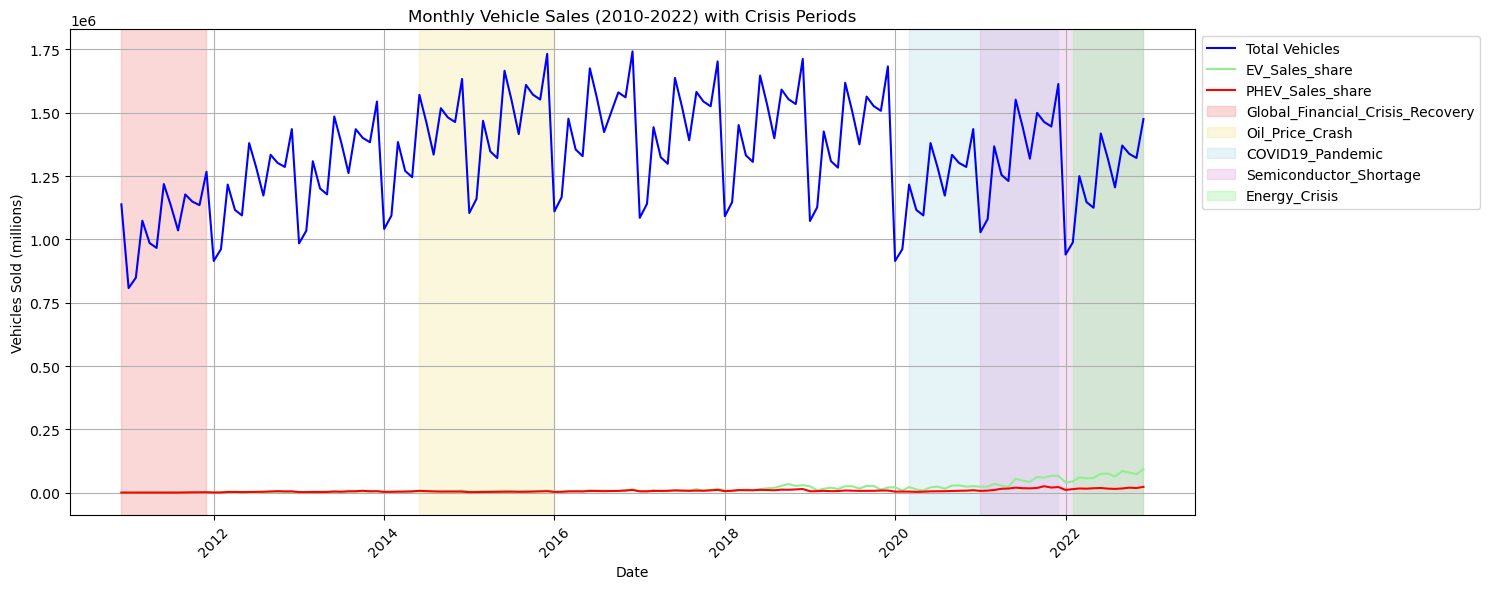

In [607]:
# Plot heatmap
# plt.figure(figsize=(8,6))
# sns.heatmap(df_monthly.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

# plt.title("Correlation Heatmap of df_monthly_2")
# plt.show()

import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(15,6))

# Plot sales lines
plt.plot(df_monthly["Date"], df_monthly["Monthly_Total"], label="Total Vehicles", color="blue")
# plt.plot(df_monthly["Date"], df_monthly["Monthly_EV"], label="EV Sales", color="green")
# plt.plot(df_monthly["Date"], df_monthly["Monthly_PHEV"], label="PHEV Sales", color="orange")
plt.plot(df_monthly["Date"], df_monthly["ev_share"], label="EV_Sales_share", color="lightgreen")
plt.plot(df_monthly["Date"], df_monthly["phev_share"], label="PHEV_Sales_share", color="red")

# Crisis periods for shading
crises_colors = {
    "Global_Financial_Crisis_Recovery": "lightcoral",
    "Oil_Price_Crash": "khaki",
    "COVID19_Pandemic": "lightblue",
    "Semiconductor_Shortage": "plum",
    "Energy_Crisis": "lightgreen"
}

# Add shaded regions for each crisis
for crisis, color in crises_colors.items():
    # find start and end dates
    active_dates = df_monthly[df_monthly[crisis]==1]["Date"]
    if not active_dates.empty:
        plt.axvspan(active_dates.min(), active_dates.max(), color=color, alpha=0.3, label=crisis)

# Chart styling
plt.title("Monthly Vehicle Sales (2010-2022) with Crisis Periods")
plt.xlabel("Date")
plt.ylabel("Vehicles Sold (millions)")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))  # move legend outside
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [608]:
df_monthly=df_monthly[["Date","Monthly_Total","Monthly_EV_market_share%","Monthly_PHEV_market_share%","ev_share","phev_share","Monthly_Total_cumsum"]]

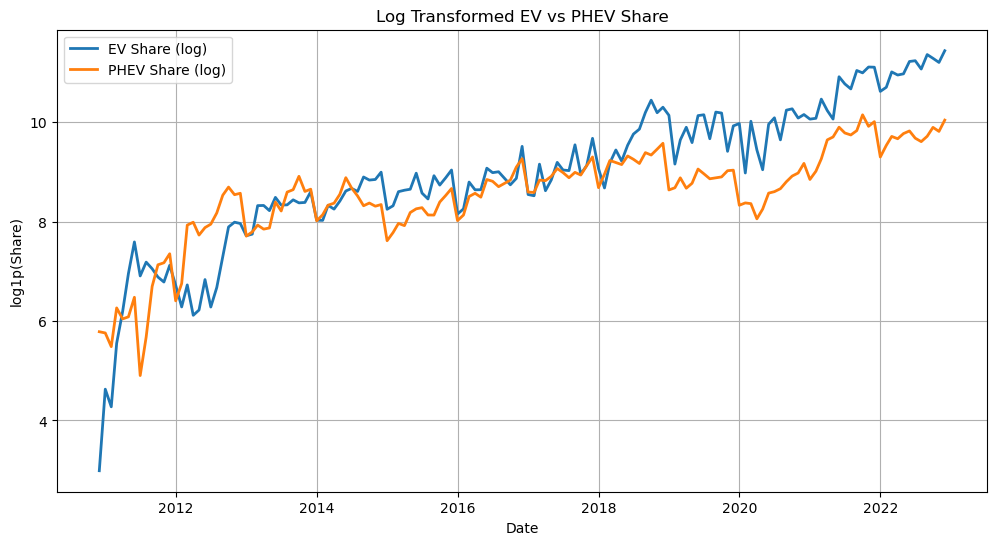

In [609]:
df_monthly["ev_share_log"] = np.log1p(df_monthly["ev_share"])
df_monthly["phev_share_log"] = np.log1p(df_monthly["phev_share"])


import matplotlib.pyplot as plt
import numpy as np

# create log features
df_monthly["ev_share_log"] = np.log1p(df_monthly["ev_share"])
df_monthly["phev_share_log"] = np.log1p(df_monthly["phev_share"])

# plot
plt.figure(figsize=(12,6))

plt.plot(
    df_monthly["Date"],
    df_monthly["ev_share_log"],
    label="EV Share (log)",
    linewidth=2
)

plt.plot(
    df_monthly["Date"],
    df_monthly["phev_share_log"],
    label="PHEV Share (log)",
    linewidth=2
)

plt.title("Log Transformed EV vs PHEV Share")
plt.xlabel("Date")
plt.ylabel("log1p(Share)")
plt.legend()
plt.grid(True)

plt.show()


In [610]:
# df_monthly.drop(columns=["ev_share","phev_share"],inplace=True)

df_prophet_ev = df_monthly[[
    "Date",
    "ev_share_log",
    "Monthly_Total",
    "Monthly_EV_market_share%",
    "Monthly_PHEV_market_share%",
    "Monthly_Total_cumsum"
]].copy()

df_prophet_ev = df_prophet_ev.rename(columns={
    "Date": "ds",
    "ev_share_log": "y"
})

df_prophet_ev = df_prophet_ev.sort_values("ds")

print(df_prophet_ev.head())


df_prophet_phev = df_monthly[[
    "Date",
    "phev_share_log",
    "Monthly_Total",
    "Monthly_EV_market_share%",
    "Monthly_PHEV_market_share%",
    "Monthly_Total_cumsum"
]].copy()

df_prophet_phev = df_prophet_phev.rename(columns={
    "Date": "ds",
    "phev_share_log": "y"
})

df_prophet_phev = df_prophet_phev.sort_values("ds")

print(df_prophet_phev.head())


          ds         y  Monthly_Total  Monthly_EV_market_share%  \
0 2010-12-01  2.990457      1138500.0                  0.000017   
1 2011-01-01  4.629474       807680.0                  0.000126   
2 2011-02-01  4.275213       848640.0                  0.000084   
3 2011-03-01  5.551823      1073920.0                  0.000239   
4 2011-04-01  6.191797       985600.0                  0.000495   

   Monthly_PHEV_market_share%  Monthly_Total_cumsum  
0                    0.000285            11500000.0  
1                    0.000391            12307680.0  
2                    0.000283            13156320.0  
3                    0.000488            14230240.0  
4                    0.000426            15215840.0  
          ds         y  Monthly_Total  Monthly_EV_market_share%  \
0 2010-12-01  5.784424      1138500.0                  0.000017   
1 2011-01-01  5.759536       807680.0                  0.000126   
2 2011-02-01  5.484878       848640.0                  0.000084   
3 201

In [611]:
df_prophet_phev

,ds,y,Monthly_Total,Monthly_EV_market_share%,Monthly_PHEV_market_share%,Monthly_Total_cumsum
0,2010-12-01,5.784424,1138500.0,0.000017,0.000285,11500000.0
1,2011-01-01,5.759536,807680.0,0.000126,0.000391,12307680.0
2,2011-02-01,5.484878,848640.0,0.000084,0.000283,13156320.0
3,2011-03-01,6.262923,1073920.0,0.000239,0.000488,14230240.0
4,2011-04-01,6.041753,985600.0,0.000495,0.000426,15215840.0
...,...,...,...,...,...,...
139,2022-08-01,9.605648,1205410.0,0.053009,0.012317,197694450.0
140,2022-09-01,9.713405,1370800.0,0.062316,0.012064,199065250.0
141,2022-10-01,9.892333,1338020.0,0.059223,0.014781,200403270.0
142,2022-11-01,9.811312,1321630.0,0.055203,0.013800,201724900.0


In [612]:
# year_df=df_monthly[["Date", "Monthly_EV_market_share%", "Monthly_PHEV_market_share%"]]
# year_df

import itertools
from prophet import Prophet
import pandas as pd
import numpy as np

# df_prophet_ev['cap'] = 1.0  # max EV share in log scale (or 100% → 1.0)
# df_prophet_ev['floor'] = 0.0  # optional, default 0


# crises_periods_with_anticipation = {
#     "Global_Financial_Crisis_Recovery": ("2010-01-01", "2012-12-31", 6),

#     "Oil_Price_Crash": ("2014-06-01", "2016-02-29", 3),

#     "COVID19_Pandemic": ("2020-03-01", "2021-06-30", 2),

#     "Semiconductor_Shortage": ("2020-12-01", "2022-12-31", 4),

#     "Energy_Crisis": ("2022-02-01", "2023-06-30", 3),

#     "Dieselgate": ("2015-09-01", "2018-12-31", 2),

#     "Tesla_Model3_Launch": ("2017-07-01", "2020-06-30", 2),

#     "Battery_Cost_Drop": ("2014-01-01", "2020-12-31", 6),

#     "Global_EV_Policy_Push": ("2019-01-01", "2023-12-31", 4),

#     "US_EV_Tax_Incentives": ("2022-08-01", "2025-12-31", 2),
# }

crises_periods_with_anticipation = {
    "Global_Financial_Crisis_Recovery": ("2010-01-01", 6, 6),
    "Oil_Price_Crash": ("2014-06-01", 3, 6),
    "COVID19_Pandemic": ("2020-03-01", 2, 12),
    "Semiconductor_Shortage": ("2021-01-01", 3, 12),
    "Energy_Crisis": ("2022-02-01", 2, 8),
    "Dieselgate": ("2015-09-01", 2, 6),
    "Tesla_Model3_Launch": ("2017-07-01", 2, 12),
    "Battery_Cost_Drop": ("2016-01-01", 6, 12),
    "Global_EV_Policy_Push": ("2019-01-01", 4, 12),
    "US_EV_Tax_Incentives": ("2022-08-01", 2, 12),
}


# rows = []

# for crisis, (start, end, anticipation_months) in crises_periods_with_anticipation.items():

#     start = pd.to_datetime(start)
#     end = pd.to_datetime(end)

#     crisis_months = (end.year - start.year) * 12 + (end.month - start.month)


rows = []

for crisis, (start, lower, upper) in crises_periods_with_anticipation.items():

    rows.append({
        "holiday": crisis,
        "ds": pd.to_datetime(start),
        "lower_window": -lower,   # anticipation months
        "upper_window": upper     # impact months
    })

crisis_holidays = pd.DataFrame(rows)

print(crisis_holidays)

                            holiday         ds  lower_window  upper_window
0  Global_Financial_Crisis_Recovery 2010-01-01            -6             6
1                   Oil_Price_Crash 2014-06-01            -3             6
2                  COVID19_Pandemic 2020-03-01            -2            12
3            Semiconductor_Shortage 2021-01-01            -3            12
4                     Energy_Crisis 2022-02-01            -2             8
5                        Dieselgate 2015-09-01            -2             6
6               Tesla_Model3_Launch 2017-07-01            -2            12
7                 Battery_Cost_Drop 2016-01-01            -6            12
8             Global_EV_Policy_Push 2019-01-01            -4            12
9              US_EV_Tax_Incentives 2022-08-01            -2            12


In [613]:
import pandas as pd
import numpy as np

def generate_time_regressors(df, date_col="ds", start_index=0):

    df = df.copy()

    # ensure datetime
    df[date_col] = pd.to_datetime(df[date_col])
    d = df[date_col]

    # basic calendar
    df["year"] = d.dt.year
    df["month"] = d.dt.month
    df["quarter"] = d.dt.quarter

    # cyclical encoding
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["quarter_sin"] = np.sin(2 * np.pi * df["quarter"] / 4)
    df["quarter_cos"] = np.cos(2 * np.pi * df["quarter"] / 4)

    # time trend (important for forecasting consistency)
    df["time_index"] = np.arange(start_index, start_index + len(df))

    # polynomial trends
    df["time_sq"] = df["time_index"] ** 2
    df["time_cube"] = df["time_index"] ** 3

    # beginning / end of year signals
    df["is_year_start"] = (df["month"] == 1).astype(int)
    df["is_year_end"] = (df["month"] == 12).astype(int)

    # Q4 sales push
    df["is_q4"] = (df["quarter"] == 4).astype(int)

    # mid-year slowdown
    df["is_mid_year"] = df["month"].isin([6, 7]).astype(int)

    # month groups
    df["month_group1"] = df["month"].isin([1, 2, 3]).astype(int)
    df["month_group2"] = df["month"].isin([4, 5, 6]).astype(int)
    df["month_group3"] = df["month"].isin([7, 8, 9]).astype(int)
    df["month_group4"] = df["month"].isin([10, 11, 12]).astype(int)

    # seasons
    df["winter"] = df["month"].isin([12, 1, 2]).astype(int)
    df["spring"] = df["month"].isin([3, 4, 5]).astype(int)
    df["summer"] = df["month"].isin([6, 7, 8]).astype(int)
    df["fall"] = df["month"].isin([9, 10, 11]).astype(int)

    return df


In [614]:
import numpy as np
import pandas as pd

def add_ev_phev_regressors(df, model=None):

    df = df.copy()
    df["ds"] = pd.to_datetime(df["ds"])

    # -----------------------------
    # Calendar effects
    # -----------------------------
    df["year_end_sales_push"] = df["ds"].dt.month.isin([11, 12]).astype(int)
    df["post_covid"] = (df["ds"] >= "2021-01-01").astype(int)

    # -----------------------------
    # Convert shares if %
    # -----------------------------
    if df["Monthly_EV_market_share%"].max() > 1:
        df["Monthly_EV_market_share%"] /= 100

    if df["Monthly_PHEV_market_share%"].max() > 1:
        df["Monthly_PHEV_market_share%"] /= 100

    # -----------------------------
    # Create EV / PHEV sales
    # -----------------------------
    df["EV_sales"] = df["Monthly_Total"] * df["Monthly_EV_market_share%"]
    df["PHEV_sales"] = df["Monthly_Total"] * df["Monthly_PHEV_market_share%"]

    df["total_vehicle_sales"] = df["Monthly_Total"]

    # -----------------------------
    # Growth calculations
    # -----------------------------
    df["EV_growth"] = df["EV_sales"].pct_change()
    df["PHEV_growth"] = df["PHEV_sales"].pct_change()

    df["sales_growth"] = df["total_vehicle_sales"].pct_change()

    # -----------------------------
    # EV / PHEV dynamics
    # -----------------------------
    df["ev_vs_phev_growth"] = df["EV_growth"] - df["PHEV_growth"]
    df["total_ev_momentum"] = df["EV_growth"] + df["PHEV_growth"]

    df["ev_growth_volatility"] = df["EV_growth"].rolling(6).std()

    df["ev_growth_acceleration"] = df["EV_growth"].diff()
    df["phev_growth_acceleration"] = df["PHEV_growth"].diff()

    df["ev_growth_trend"] = df["EV_growth"].rolling(12).mean()
    df["phev_growth_trend"] = df["PHEV_growth"].rolling(12).mean()

    df["ev_share_growth"] = df["EV_growth"] / (
        df["EV_growth"] + df["PHEV_growth"] + 1e-6
    )

    # -----------------------------
    # Market dynamics
    # -----------------------------
    df["phev_market_share"] = df["PHEV_sales"] / df["total_vehicle_sales"]
    df["ev_market_share"] = df["EV_sales"] / df["total_vehicle_sales"]

    df["electrification_share"] = (
        df["EV_sales"] + df["PHEV_sales"]
    ) / df["total_vehicle_sales"]

    # -----------------------------
    # Replace inf / NaN
    # -----------------------------
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(method="bfill", inplace=True)
    df.fillna(method="ffill", inplace=True)

    # -----------------------------
    # Regressor list
    # -----------------------------
    regressors = [
        "year_end_sales_push",
        "post_covid",
        "ev_vs_phev_growth",
        "total_ev_momentum",
        "ev_growth_volatility",
        "ev_growth_acceleration",
        "phev_growth_acceleration",
        "ev_growth_trend",
        "phev_growth_trend",
        "ev_share_growth",
        "sales_growth",
        "phev_market_share",
        "ev_market_share",
        "electrification_share",
    ]

    # -----------------------------
    # Register regressors in Prophet
    # -----------------------------
    if model is not None:
        for r in regressors:
            model.add_regressor(r)

    return df, regressors


In [615]:
# -----------------------------
# Feature engineering
# -----------------------------
df_prophet_ev["ds"] = pd.to_datetime(df_prophet_ev["ds"])

df_prophet_ev, ev_regressors = add_ev_phev_regressors(df_prophet_ev)

df_prophet_ev = generate_time_regressors(df_prophet_ev)


# -----------------------------
# Time-based regressors
# -----------------------------
time_regressors = [
    "year","month","quarter",
    "time_index","time_sq","time_cube",
    "month_sin","month_cos",
    "quarter_sin","quarter_cos",
    "is_year_start","is_year_end",
    "is_q4","is_mid_year",
    "winter","spring","summer","fall"
]


# combine and remove duplicates
all_regressors = list(set(time_regressors + ev_regressors))


# -----------------------------
# Prophet model
# -----------------------------
from prophet import Prophet

m = Prophet(
    growth="linear",
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=crisis_holidays,
    seasonality_mode="additive",   #multiplicative
    seasonality_prior_scale=10,
    holidays_prior_scale=10,
    changepoint_prior_scale=0.05
)

# -----------------------------
# Long-term EV adoption cycles
# -----------------------------
# m.add_seasonality(
#     name="biannual",
#     period=365.25 * 2,
#     fourier_order=5
# )

# m.add_seasonality(
#     name="three_year_cycle",
#     period=365.25 * 3,
#     fourier_order=5
# )

# m.add_seasonality(
#     name="ev_adoption_cycle",
#     period=365.25 * 4,
#     fourier_order=5
# )

# -----------------------------
# Add regressors safely
# -----------------------------
for r in all_regressors:
    if r in df_prophet_ev.columns:
        m.add_regressor(r)


# -----------------------------
# Clean training data
# -----------------------------
training_set = df_prophet_ev.copy()

training_set.replace([np.inf, -np.inf], np.nan, inplace=True)

# drop rows where y or regressors are missing
training_set = training_set.dropna(subset=["y"] + all_regressors)


# -----------------------------
# Train model
# -----------------------------
m.fit(training_set)


13:48:04 - cmdstanpy - INFO - Chain [1] start processing
13:48:05 - cmdstanpy - INFO - Chain [1] done processing


In [616]:
# -----------------------------
# Create future dates
# -----------------------------
future_dates = pd.date_range(
    start=df_prophet_ev["ds"].iloc[-1] + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

future = pd.DataFrame({"ds": future_dates})

# -----------------------------
# Add base columns
# -----------------------------
last_row = df_prophet_ev.iloc[-1]

future["Monthly_Total"] = last_row["Monthly_Total"]
future["Monthly_EV_market_share%"] = last_row["Monthly_EV_market_share%"]
future["Monthly_PHEV_market_share%"] = last_row["Monthly_PHEV_market_share%"]

# -----------------------------
# Time regressors
# -----------------------------
future = generate_time_regressors(
    future,
    start_index=df_prophet_ev["time_index"].max() + 1
)

# -----------------------------
# Copy EV regressors from last known values
# -----------------------------
for r in ev_regressors:
    future[r] = last_row[r]

# -----------------------------
# Clean dataframe
# -----------------------------
future.replace([np.inf, -np.inf], np.nan, inplace=True)
future.fillna(method="ffill", inplace=True)
future.fillna(method="bfill", inplace=True)

# -----------------------------
# Forecast
# -----------------------------
forecast = m.predict(future)

forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(12)


,ds,yhat,yhat_lower,yhat_upper
0,2023-01-01,12.649996,12.425597,12.863000
1,2023-02-01,10.950072,10.725744,11.166655
2,2023-03-01,10.570300,10.347616,10.789938
3,2023-04-01,11.837758,11.621094,12.053058
4,2023-05-01,11.537862,11.361222,11.749139
5,2023-06-01,10.944891,10.726119,11.158611
6,2023-07-01,11.651000,11.459819,11.865117
7,2023-08-01,11.449125,11.215572,11.650515
8,2023-09-01,10.969772,10.759201,11.178216
9,2023-10-01,11.238931,11.031441,11.475979


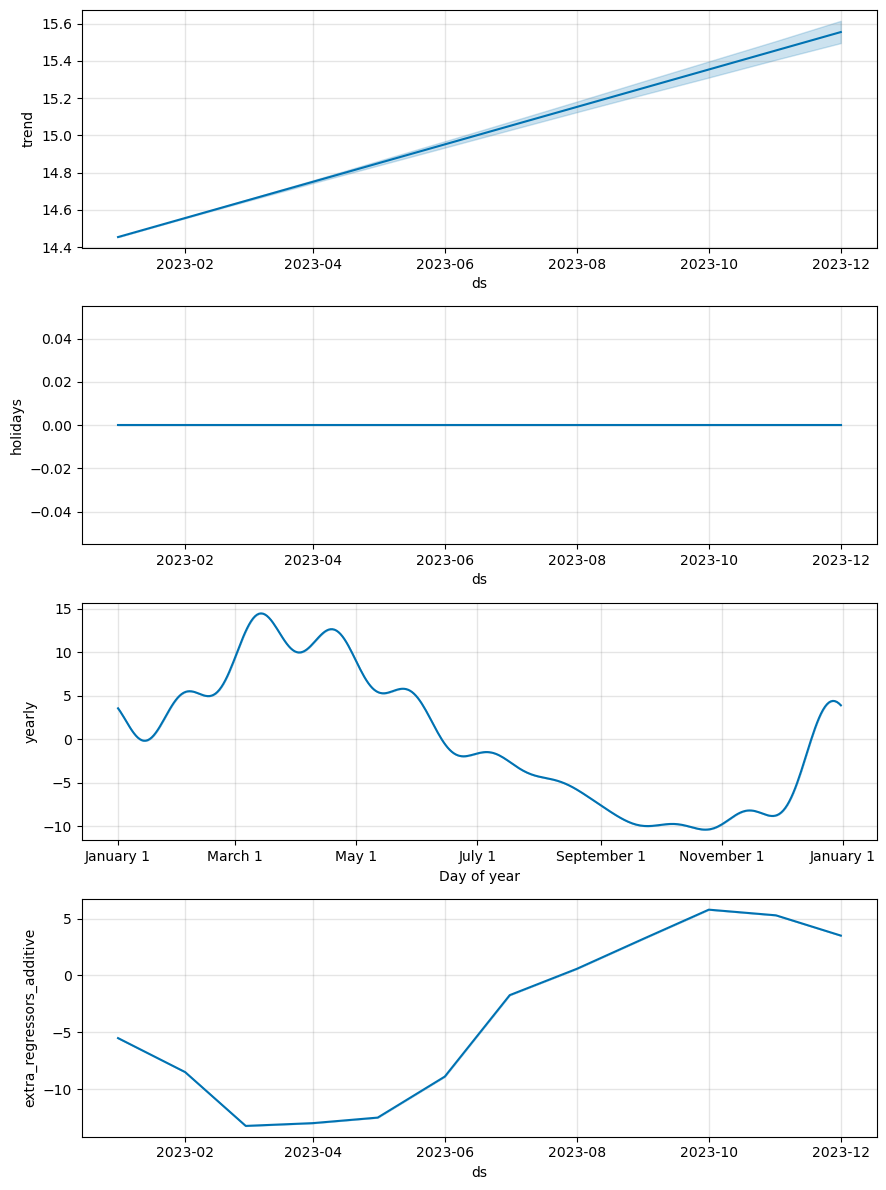

In [617]:
m.plot_components(forecast)

In [550]:
forecast["ev_share"] = np.expm1(forecast["yhat"])
# forecast["phev_share"] = np.expm1(forecast["phev_share_log"])
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Battery_Cost_Drop,Battery_Cost_Drop_lower,Battery_Cost_Drop_upper,COVID19_Pandemic,...,year_end_sales_push_lower,year_end_sales_push_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,ev_share
0,2023-01-01,13.815034,12.482472,12.902714,13.815034,13.815034,0.0,0.0,0.0,0.0,...,0.224153,0.224153,3.160606,3.160606,3.160606,0.0,0.0,0.0,12.697689,326990.234597
1,2023-02-01,13.907327,10.768734,11.206596,13.905775,13.908412,0.0,0.0,0.0,0.0,...,0.224153,0.224153,3.656019,3.656019,3.656019,0.0,0.0,0.0,10.982164,58814.715082
2,2023-03-01,13.990689,10.415003,10.844049,13.986603,13.994000,0.0,0.0,0.0,0.0,...,0.224153,0.224153,6.660919,6.660919,6.660919,0.0,0.0,0.0,10.625434,41167.706001
3,2023-04-01,14.082982,11.654025,12.094817,14.076195,14.088938,0.0,0.0,0.0,0.0,...,0.224153,0.224153,7.519626,7.519626,7.519626,0.0,0.0,0.0,11.867880,142610.638471
4,2023-05-01,14.172298,11.350493,11.791418,14.161418,14.181949,0.0,0.0,0.0,0.0,...,0.224153,0.224153,6.813046,6.813046,6.813046,0.0,0.0,0.0,11.573545,106248.439199
5,2023-06-01,14.264591,10.781971,11.209293,14.247885,14.279231,0.0,0.0,0.0,0.0,...,0.224153,0.224153,3.572144,3.572144,3.572144,0.0,0.0,0.0,10.980860,58738.073170
6,2023-07-01,14.353907,11.469674,11.928429,14.331612,14.374093,0.0,0.0,0.0,0.0,...,0.224153,0.224153,-1.171655,-1.171655,-1.171655,0.0,0.0,0.0,11.690073,119379.726415
7,2023-08-01,14.446200,11.247314,11.694940,14.418251,14.471783,0.0,0.0,0.0,0.0,...,0.224153,0.224153,-3.130351,-3.130351,-3.130351,0.0,0.0,0.0,11.467481,95556.240370
8,2023-09-01,14.538493,10.770623,11.212409,14.502533,14.572422,0.0,0.0,0.0,0.0,...,0.224153,0.224153,-5.674081,-5.674081,-5.674081,0.0,0.0,0.0,10.994989,59573.882917
9,2023-10-01,14.627808,11.036672,11.496580,14.585135,14.669055,0.0,0.0,0.0,0.0,...,0.224153,0.224153,-7.399130,-7.399130,-7.399130,0.0,0.0,0.0,11.275838,78891.212779


In [475]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
from prophet import Prophet

df = df_prophet_ev.copy()
df["ds"] = pd.to_datetime(df["ds"])

initial_window = 60
horizon = 12
step = 12

mape_scores = []
all_predictions = []

for start in range(initial_window, len(df) - horizon, step):

    train = df.iloc[:start].copy()
    test = df.iloc[start:start + horizon].copy()

    m = Prophet(
        growth="linear",
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        holidays=crisis_holidays,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05
    )

    # -----------------------------
    # Long-term EV adoption cycles
    # -----------------------------
    # m.add_seasonality(
    #     name="biannual",
    #     period=365.25 * 2,
    #     fourier_order=5
    # )
    
    # m.add_seasonality(
    #     name="three_year_cycle",
    #     period=365.25 * 3,
    #     fourier_order=5
    # )
    
    # m.add_seasonality(
    #     name="ev_adoption_cycle",
    #     period=365.25 * 4,
    #     fourier_order=5
    # )

    for r in all_regressors:
        if r in train.columns:
            m.add_regressor(r)

    m.fit(train)

    future = test[["ds"] + all_regressors]

    forecast = m.predict(future)

    pred = forecast["yhat"].values
    actual = test["y"].values

    mape = mean_absolute_percentage_error(actual, pred)
    mape_scores.append(mape)

    temp = pd.DataFrame({
        "ds": test["ds"],
        "actual": actual,
        "forecast": pred,
        "lower": forecast["yhat_lower"].values,
        "upper": forecast["yhat_upper"].values
    })


    all_predictions.append(temp)

# combine folds
results = pd.concat(all_predictions)

print("MAPE per fold:", mape_scores)
print("Mean MAPE:", np.mean(mape_scores))

ValueError: Capacities must be supplied for logistic growth in column "cap"

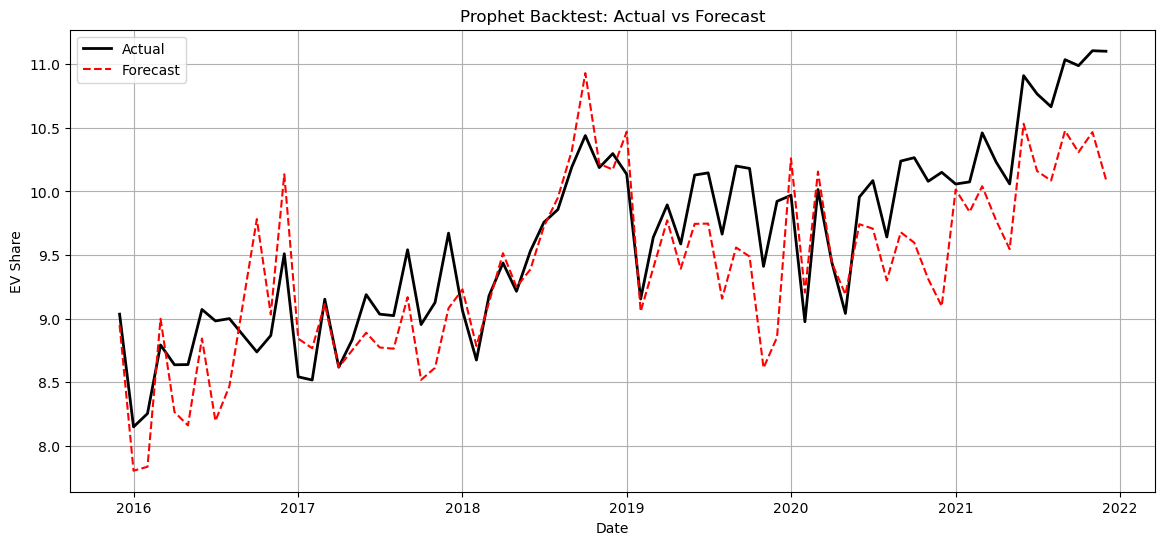

In [473]:
# Mean MAPE: 0.1482354763597465

plt.figure(figsize=(14,6))

plt.plot(results["ds"], results["actual"], label="Actual", color="black", linewidth=2)
plt.plot(results["ds"], results["forecast"], label="Forecast", color="red", linestyle="--")

plt.title("Prophet Backtest: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("EV Share")
plt.legend()
plt.grid(True)

plt.show()

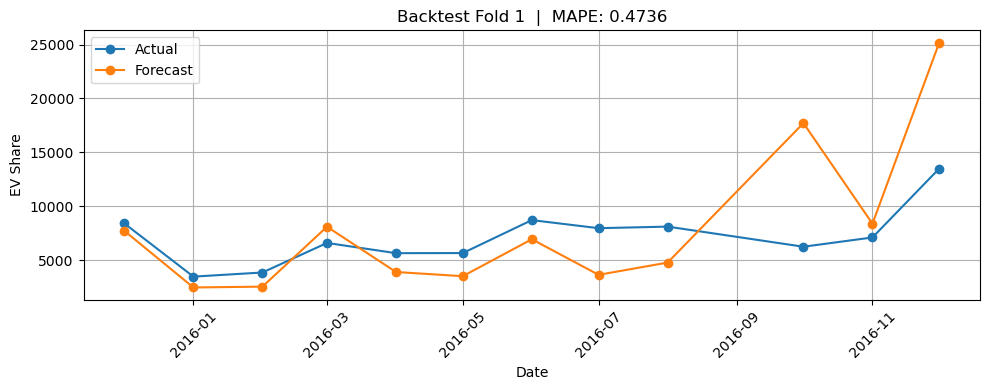

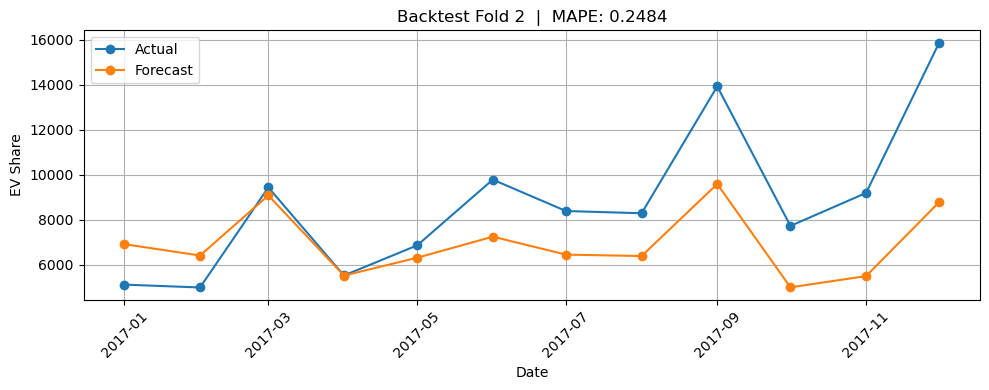

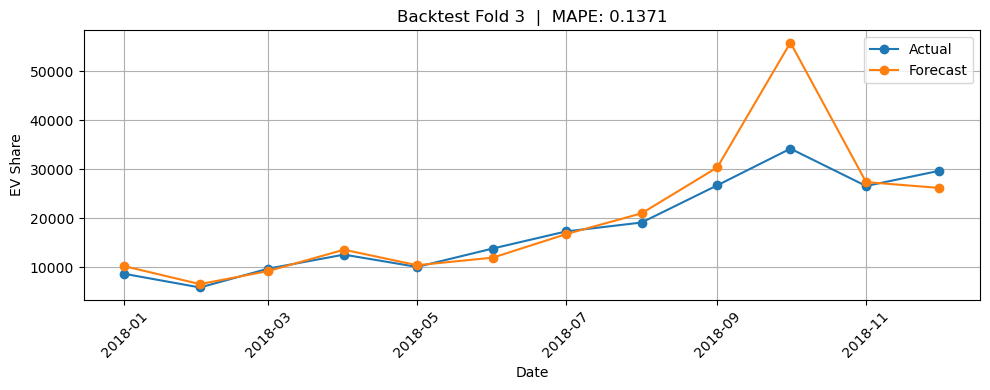

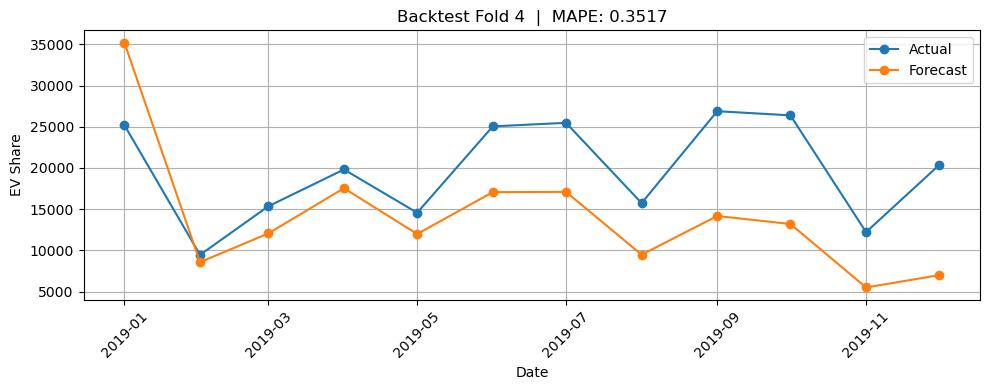

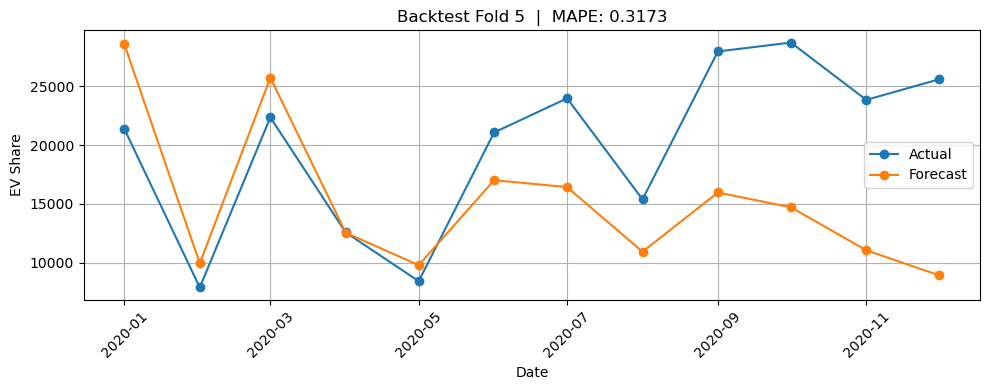

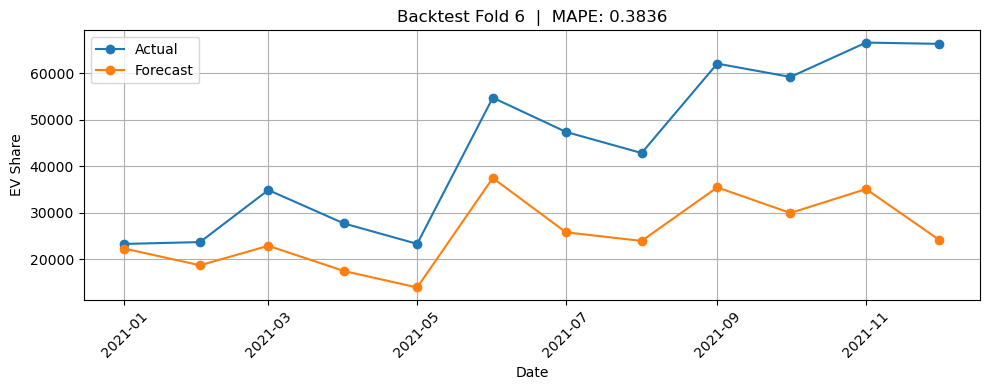

MAPE per fold: [0.4735516102151108, 0.24836374292032834, 0.13714204470845373, 0.3517435017975968, 0.31733903339468067, 0.3835582460236359]
Mean MAPE: 0.3186163631766344


In [474]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

fold_mapes = []

for i, df_fold in enumerate(all_predictions):

    df_fold = df_fold.copy()

    # convert back from log
    df_fold["actual"] = np.expm1(df_fold["actual"])
    df_fold["forecast"] = np.expm1(df_fold["forecast"])

    # compute MAPE
    mape = mean_absolute_percentage_error(df_fold["actual"], df_fold["forecast"])
    fold_mapes.append(mape)

    # plot
    plt.figure(figsize=(10,4))

    plt.plot(df_fold["ds"], df_fold["actual"], label="Actual", marker="o")
    plt.plot(df_fold["ds"], df_fold["forecast"], label="Forecast", marker="o")

    plt.title(f"Backtest Fold {i+1}  |  MAPE: {mape:.4f}")
    plt.xlabel("Date")
    plt.ylabel("EV Share")
    plt.legend()
    plt.grid(True)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# print summary
print("MAPE per fold:", fold_mapes)
print("Mean MAPE:", np.mean(fold_mapes))


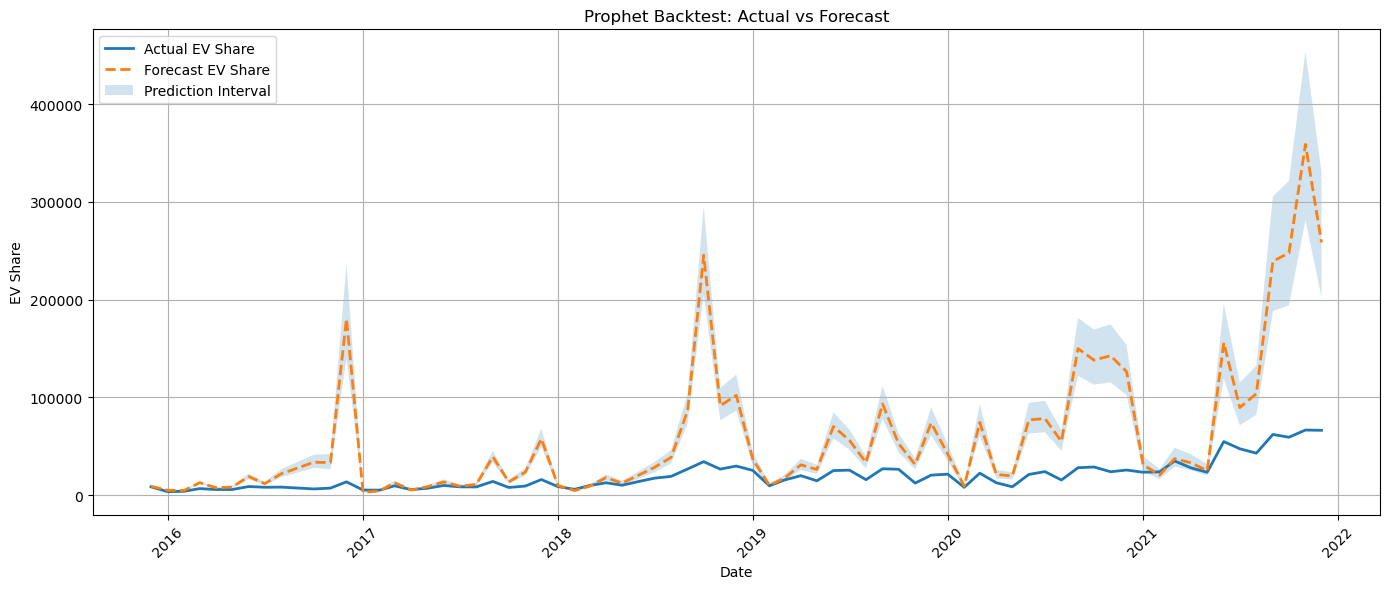

In [469]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure datetime
results["ds"] = pd.to_datetime(results["ds"])

# Convert from log scale safely
actual = np.expm1(results["actual"])
forecast = np.expm1(results["forecast"])

lower = np.expm1(results["lower"]) if "lower" in results.columns else None
upper = np.expm1(results["upper"]) if "upper" in results.columns else None

plt.figure(figsize=(14,6))

# Actual line
plt.plot(
    results["ds"],
    actual,
    label="Actual EV Share",
    linewidth=2
)

# Forecast line
plt.plot(
    results["ds"],
    forecast,
    linestyle="--",
    linewidth=2,
    label="Forecast EV Share"
)

# Prediction interval (only if available)
if lower is not None and upper is not None:
    plt.fill_between(
        results["ds"].values,
        lower.values,
        upper.values,
        alpha=0.2,
        label="Prediction Interval"
    )

plt.title("Prophet Backtest: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("EV Share")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [202]:
# use  for "ev_share" estimator = TBATS(
                #     seasonal_periods=12,
                #     use_box_cox=False,
                #     use_trend=True,
                #     use_damped_trend=False
                # )

# for "phev_share" keep the same as below 


# year_df=df_monthly[["Date", "ev_share", "phev_share"]]  

# year_df = year_df.tail(36)

# from statsmodels.tsa.holtwinters import ExponentialSmoothing

# year_df["Date"] = pd.to_datetime(year_df["Date"])
# year_df = year_df.set_index("Date")
# year_df = year_df.asfreq("MS")

# year_df_numeric = year_df.select_dtypes(include="number")

# forecast_all = {}

# for col in year_df_numeric.columns:

#     series = year_df_numeric[col].dropna()

#     model = ExponentialSmoothing(
#         series,
#         trend="additive",
#         seasonal=None,
#     ).fit()

#     # model = ExponentialSmoothing(
#     #     series,
#     #     trend="add",
#     #     damped_trend=True,
#     #     seasonal="mul",
#     #     seasonal_periods=12
#     # ).fit()

#     pred = model.forecast(12)

#     forecast_all[col] = pred.values


# # 1. Your input dictionary
# data_dict = forecast_all

# # 2. Create the Date index for 2023
# # 'MS' stands for Month Start (2023-01-01, 2023-02-01, etc.)
# dates = pd.date_range(start='2023-01-01', periods=12, freq='MS')

# # 3. Initialize the DataFrame
# forcast_df = pd.DataFrame(data_dict)

# # 4. Insert the Date column and set it as the index
# forcast_df['Date'] = dates
# forcast_df = forcast_df[['Date', 'ev_share', 'phev_share']] # Reordering columns

# # 5. Display the result
# print(forcast_df)

In [217]:
import pandas as pd
from tbats import TBATS
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# year_df = df_monthly[["Date", "ev_share", "phev_share"]]

# year_df["Date"] = pd.to_datetime(year_df["Date"])
# year_df = year_df.set_index("Date")
# year_df = year_df.asfreq("MS")

# year_df_numeric = year_df.select_dtypes(include="number")


# from statsmodels.tsa.stattools import adfuller

# for col in year_df_numeric.columns:

#     series = year_df_numeric[col].dropna()
    
#     result = adfuller(series)

#     print(f"\n===== {col} =====")
#     print("ADF Statistic:", result[0])
#     print("p-value:", result[1])
#     print("Lags Used:", result[2])
#     print("Observations:", result[3])

#     print("Critical Values:")
#     for key, value in result[4].items():
#         print(f"   {key}: {value}")

#     if result[1] <= 0.05:
#         print("Result: Stationary")
#     else:
#         print("Result: Non-Stationary")


===== ev_share =====
ADF Statistic: 0.8746971896561919
p-value: 0.9927510718638635
Lags Used: 13
Observations: 118
Critical Values:
   1%: -3.4870216863700767
   5%: -2.8863625166643136
   10%: -2.580009026141913
Result: Non-Stationary

===== phev_share =====
ADF Statistic: -1.0017675959169114
p-value: 0.7526190653650897
Lags Used: 12
Observations: 119
Critical Values:
   1%: -3.4865346059036564
   5%: -2.8861509858476264
   10%: -2.579896092790057
Result: Non-Stationary


In [204]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from tbats import TBATS
# from statsmodels.tsa.holtwinters import ExponentialSmoothing
# import numpy as np

# def walk_forward_backtest(
#         data,
#         model_type="tbats",
#         start_train="2020-01-01",
#         start_test="2022-01-01",
#         seasonal_periods=[12]
#     ):

#     data = data.copy()

#     predictions = {col: [] for col in data.columns}
#     actuals = {col: [] for col in data.columns}
#     dates = []

#     test_dates = data.loc[start_test:].index

#     for current_date in test_dates:

#         train = data.loc[start_train:current_date - pd.offsets.MonthBegin(1)]

#         for col in data.columns:

#             series = train[col].dropna()

#             # ----- Model Selection -----
#             if model_type == "tbats":

#                 estimator = TBATS(
#                     seasonal_periods=seasonal_periods,
#                     use_box_cox=False,
#                     use_trend=True,
#                     use_damped_trend=False
#                 )

#                 model = estimator.fit(series)
#                 pred = model.forecast(steps=1)[0]

#             elif model_type == "ets":

#                 model = ExponentialSmoothing(
#                     series,
#                     trend="add",
#                     seasonal=None
#                 ).fit()

#                 pred = model.forecast(1)[0]

#             else:
#                 raise ValueError("Unknown model")

#             predictions[col].append(pred)
#             actuals[col].append(data.loc[current_date, col])

#         dates.append(current_date)

#     # Convert to DataFrames
#     pred_df = pd.DataFrame(predictions, index=dates)
#     actual_df = pd.DataFrame(actuals, index=dates)

#     # -------- Plot --------
#     plt.figure(figsize=(12,6))

#     for col in data.columns:
#         plt.plot(data.index, data[col], label=f"{col} actual")
#         plt.plot(pred_df.index, pred_df[col], "--", label=f"{col} forecast")

#     plt.title(f"Walk-Forward Backtest ({model_type})")
#     plt.xlabel("Date")
#     plt.ylabel("Value")
#     plt.legend()
#     plt.show()

#     # -------- Metrics --------
#     print("\nBacktest Metrics")

#     for col in data.columns:
#         mape = (np.abs((actual_df[col] - pred_df[col]) / actual_df[col])).mean() * 100
#         print(f"{col}: MAPE = {mape:.2f}%")

#     return pred_df, actual_df

# walk_forward_backtest(
#     year_df_numeric,
#     model_type="ets",
#     seasonal_periods=[3,4,6,12,24]
# )

In [205]:
# from prophet import Prophet

# # ensure datetime
# year_df["Date"] = pd.to_datetime(year_df["Date"])

# # regressors list
# regressors = [
#     # "Global_Financial_Crisis_Recovery",
#     # "Oil_Price_Crash",
#     # "COVID19_Pandemic",
#     # "Semiconductor_Shortage",
#     # "Energy_Crisis"
# ]

# # -------------------------
# # EV dataset
# # -------------------------
# ev_df = year_df.rename(columns={
#     "Date": "ds",
#     "ev_share": "y"
# })[["ds", "y"] + regressors]


# # -------------------------
# # PHEV dataset
# # -------------------------
# phev_df = year_df.rename(columns={
#     "Date": "ds",
#     "phev_share": "y"
# })[["ds", "y"] + regressors]


# # -------------------------
# # EV model
# # -------------------------
# ev_model = Prophet()

# for r in regressors:
#     ev_model.add_regressor(r)

# ev_model.fit(ev_df)


# # -------------------------
# # PHEV model
# # -------------------------
# phev_model = Prophet()

# for r in regressors:
#     phev_model.add_regressor(r)

# phev_model.fit(phev_df)


# # -------------------------
# # future dataframe
# # -------------------------
# ev_future = ev_model.make_future_dataframe(periods=12, freq="MS")
# phev_future = phev_model.make_future_dataframe(periods=12, freq="MS")


# # merge external factors
# reg_df = year_df[["Date"] + regressors].rename(columns={"Date": "ds"})

# ev_future = ev_future.merge(reg_df, on="ds", how="left")
# phev_future = phev_future.merge(reg_df, on="ds", how="left")


# # fill future values
# for r in regressors:
#     ev_future[r] = ev_future[r].ffill()
#     phev_future[r] = phev_future[r].ffill()


# # -------------------------
# # prediction
# # -------------------------
# ev_forecast = ev_model.predict(ev_future)
# phev_forecast = phev_model.predict(phev_future)


# # -------------------------
# # combine forecast
# # -------------------------
# forecast = pd.DataFrame({
#     "Date": ev_forecast["ds"],
#     "ev_share_pred": ev_forecast["yhat"],
#     "phev_share_pred": phev_forecast["yhat"]
# })


# # -------------------------
# # plots
# # -------------------------
# ev_model.plot(ev_forecast)
# phev_model.plot(phev_forecast)

In [206]:
# forecast_prophet=forecast.tail(12).set_index("Date").rename(columns={"ev_share_pred":"ev_share","phev_share_pred":"phev_share"})
# forecast_prophet

In [207]:
# forecast_all = {}

# for col in year_df_numeric.columns:
#     series = year_df_numeric[col].dropna()
    
#     # Initialize TBATS model
#     estimator = TBATS(
#         seasonal_periods=[4,6,12,24],  # monthly seasonality
#         use_box_cox=True,
#         use_trend=True,
#         use_damped_trend=True
#     )
    
#     # Fit the model
#     model = estimator.fit(series)
    
#     # Forecast next 12 months
#     pred = model.forecast(steps=12)
    
#     forecast_all[col] = pred

# # --- Convert forecast dictionary to a DataFrame with Date index for 2023 ---
# dates = pd.date_range(start='2023-01-01', periods=12, freq='MS')

# forcast_df = pd.DataFrame(forecast_all)
# forcast_df['Date'] = dates
# forcast_df = forcast_df[['Date', 'ev_share', 'phev_share']]  # reorder columns

# print(forcast_df)

In [208]:
from sktime.forecasting.compose import RecursiveTabularRegressionForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_selection import ExpandingWindowSplitter
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

df = df_monthly.copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

# important for sktime
df = df.asfreq("MS")

df[["ev_share","phev_share"]] = df[["ev_share","phev_share"]].interpolate()

# targets
y = df[["ev_share","phev_share"]]

# predictors
X = df.drop(columns=["ev_share","phev_share"])



from sktime.forecasting.base import ForecastingHorizon

fh = ForecastingHorizon(range(1,13), is_relative=True)

# model = RecursiveTabularRegressionForecaster(
#     estimator=RandomForestRegressor(
#         n_estimators=500,
#         max_depth=8,
#         random_state=42,
#         n_jobs=-1
#     ),
#     window_length=12
# )

# # from xgboost import XGBRegressor

# # model = RecursiveTabularRegressionForecaster(
# #     estimator=XGBRegressor(
# #         n_estimators=500,
# #         max_depth=6,
# #         learning_rate=0.05,
# #         subsample=0.9,
# #         colsample_bytree=0.9,
# #         random_state=42,
# #         n_jobs=-1
# #     ),
# #     window_length=12
# # )

# cv = ExpandingWindowSplitter(
#     initial_window=24,
#     step_length=12,
#     fh=range(1,13)
# )

# mape_scores = []

# for train_idx, test_idx in cv.split(y):

#     y_train = y.iloc[train_idx]
#     y_test = y.iloc[test_idx]

#     X_train = X.iloc[train_idx]
#     X_test = X.iloc[test_idx]

#     model.fit(y_train, X=X_train)

#     pred = model.predict(fh, X=X_test)

#     mape = mean_absolute_percentage_error(y_test, pred)

#     mape_scores.append(mape)

# print("MAPE per fold:", mape_scores)
# print("Mean MAPE:", np.mean(mape_scores))

In [209]:
from sktime.forecasting.compose import RecursiveTabularRegressionForecaster
from sklearn.ensemble import RandomForestRegressor

from sktime.forecasting.compose import RecursiveTabularRegressionForecaster
from lightgbm import LGBMRegressor

model = RecursiveTabularRegressionForecaster(
    estimator=LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ),
    window_length=12
)


model.fit(y=y, X=X)


future_index = pd.date_range(
    start=df.index[-1] + pd.offsets.MonthBegin(),
    periods=12,
    freq="MS"
)

X_future = pd.DataFrame(
    X.iloc[-1].values.repeat(12).reshape(12,-1),
    columns=X.columns,
    index=future_index
)

y_pred = model.predict(fh=fh, X=X_future)

print(y_pred)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25197
[LightGBM] [Info] Number of data points in the train set: 121, number of used features: 701
[LightGBM] [Info] Start training from score 19849.028770
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

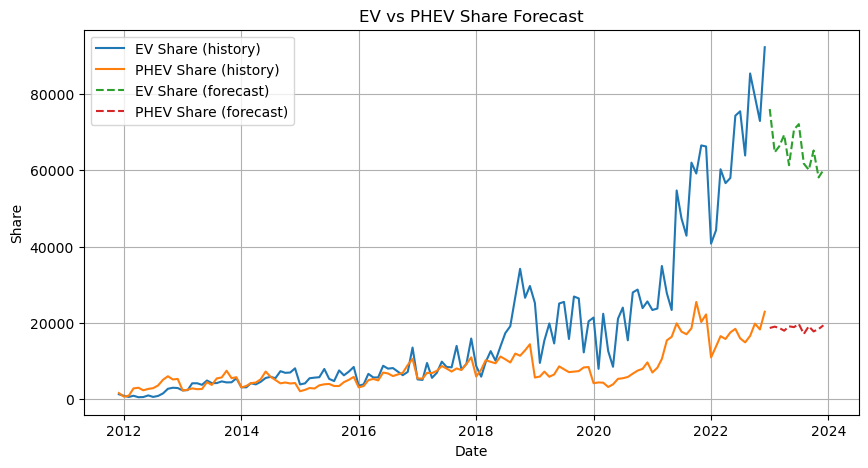

In [213]:
import matplotlib.pyplot as plt

# combine historical shares with predictions
df_plot = pd.concat([df[["ev_share","phev_share"]], forcast_df], axis=0)

# historical data
plt.figure(figsize=(10,5))
plt.plot(df.index, df["ev_share"], label="EV Share (history)")
plt.plot(df.index, df["phev_share"], label="PHEV Share (history)")

# forecast data (dashed)
plt.plot(y_pred.index, y_pred["ev_share"], "--", label="EV Share (forecast)")
plt.plot(y_pred.index, y_pred["phev_share"], "--", label="PHEV Share (forecast)")

plt.title("EV vs PHEV Share Forecast")
plt.xlabel("Date")
plt.ylabel("Share")
plt.legend()
plt.grid(True)

plt.show()

In [214]:
import pandas as pd

forecast = forcast_df
    
months = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

rows = []

# EV rows
for m, v in zip(months, forecast["ev_share"]):
    rows.append({"Periodo": f"{m}-EV", "Ventas": v})

# PHEV rows
for m, v in zip(months, forecast["phev_share"]):
    rows.append({"Periodo": f"{m}-PHEV", "Ventas": v})

df_final = pd.DataFrame(rows)

print(df_final)

     Periodo         Ventas
0     Ene-EV   83114.661369
1     Feb-EV   85095.056482
2     Mar-EV   87075.451594
3     Abr-EV   89055.846707
4     May-EV   91036.241819
5     Jun-EV   93016.636932
6     Jul-EV   94997.032045
7     Ago-EV   96977.427157
8     Sep-EV   98957.822270
9     Oct-EV  100938.217383
10    Nov-EV  102918.612495
11    Dic-EV  104899.007608
12  Ene-PHEV   21786.170614
13  Feb-PHEV   21945.245439
14  Mar-PHEV   22104.320264
15  Abr-PHEV   22263.395089
16  May-PHEV   22422.469914
17  Jun-PHEV   22581.544739
18  Jul-PHEV   22740.619563
19  Ago-PHEV   22899.694388
20  Sep-PHEV   23058.769213
21  Oct-PHEV   23217.844038
22  Nov-PHEV   23376.918863
23  Dic-PHEV   23535.993688


In [215]:
from datetime import datetime

time = datetime.now().strftime("%Y%m%d_%H%M%S")

df_final.to_csv("submission_surv_{}.csv".format(time), index=False)